                              COMPREHENSIVE EDA & STATISTICAL ANALYSIS

✓ Training set: 630000 records, 13 features
✓ Test set: 270000 records, 12 features
✓ Test set has target (exam_score): False

2. DATA QUALITY REPORT

--- TRAINING SET ---
Shape: (630000, 13)

Missing Values:
  ✓ No missing values detected

Duplicate Rows: 0

Data Types:
  int64: 2 columns
  object: 7 columns
  float64: 4 columns

Memory Usage: 257.28 MB

--- TEST SET ---
Shape: (270000, 12)

Missing Values:
  ✓ No missing values detected

Duplicate Rows: 0

Data Types:
  int64: 2 columns
  object: 7 columns
  float64: 3 columns

Memory Usage: 108.20 MB

Numerical Features (4): ['age', 'study_hours', 'class_attendance', 'sleep_hours']
Categorical Features (7): ['gender', 'course', 'internet_access', 'sleep_quality', 'study_method', 'facility_rating', 'exam_difficulty']

4. COMPREHENSIVE NUMERICAL STATISTICS

--- TRAINING SET ---


FEATURE: AGE

  Basic Statistics:
    Count:        630000
    Mean:         20.5458


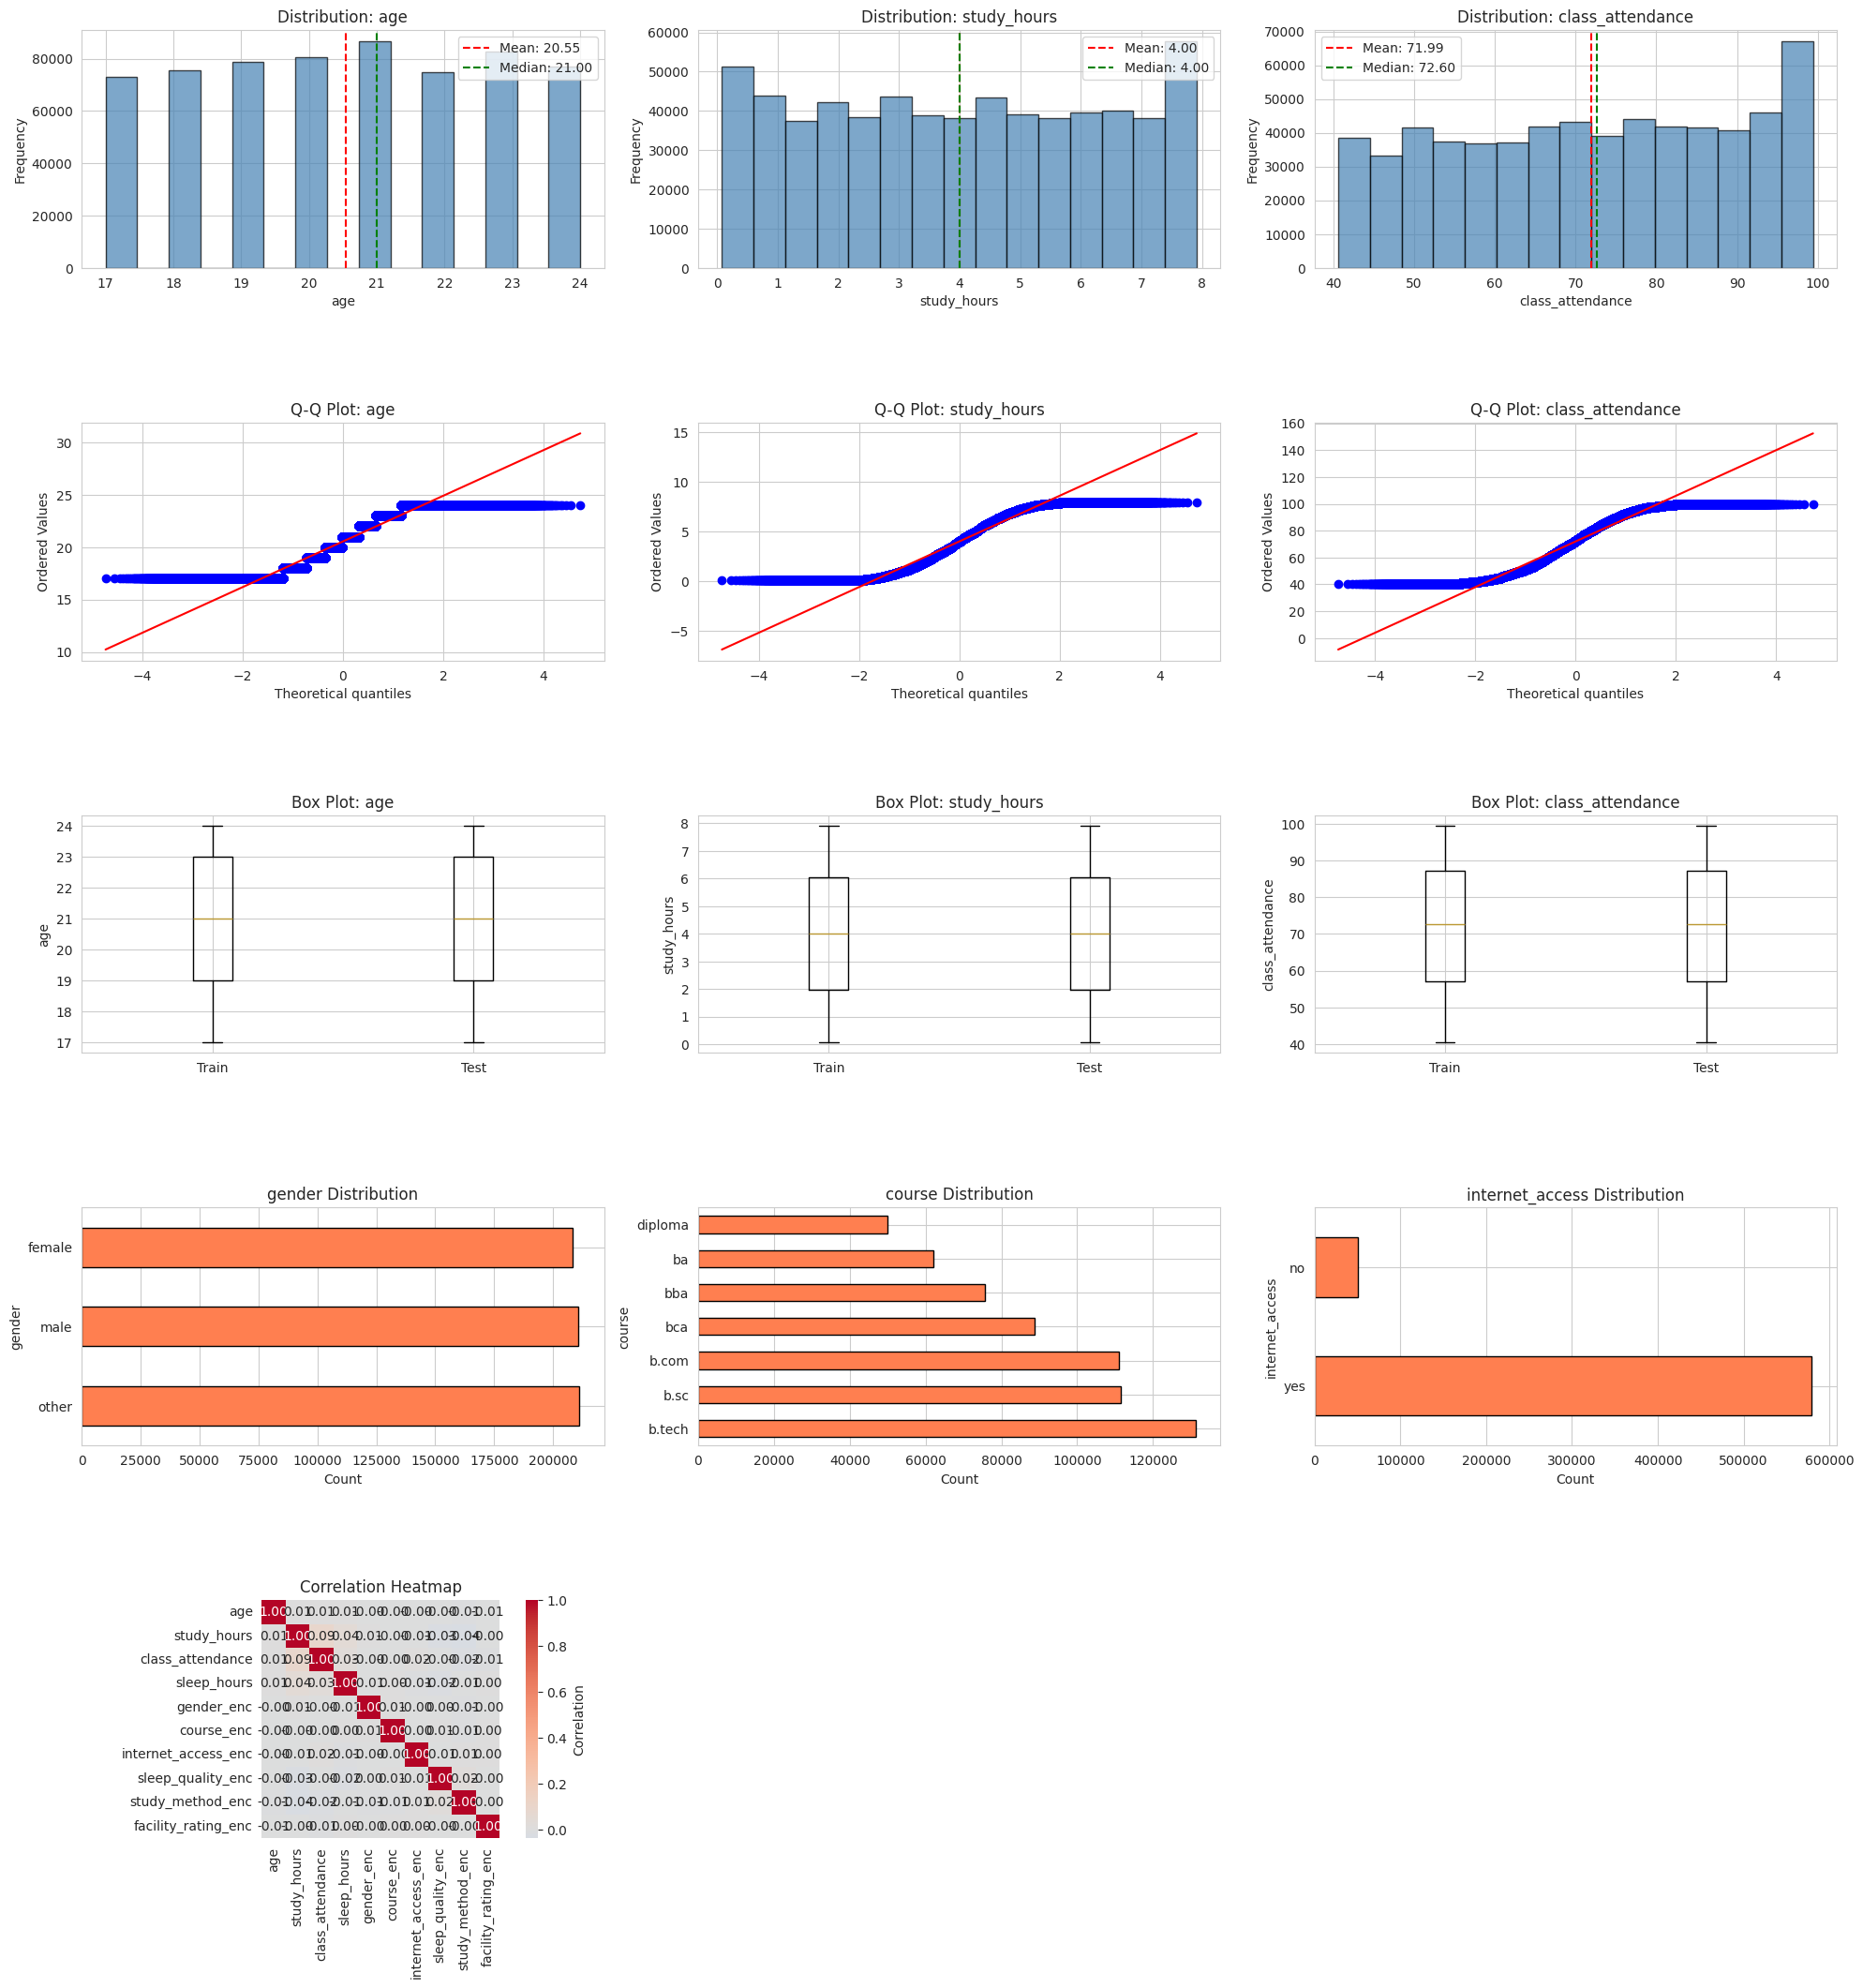


13. SUMMARY & RECOMMENDATIONS

--- KEY FINDINGS ---

  1. Dataset Size:
     - Train: 630000 samples
     - Test: 270000 samples

  2. Data Quality:
     - No missing values detected
     - No duplicates detected
     - All features are properly typed

  3. Feature Characteristics:
     - Numerical features: 4 (age, study_hours, class_attendance, sleep_hours)
     - Categorical features: 7
     - Total features: 11

--- RECOMMENDATIONS FOR MODELING ---

  1. Preprocessing:
     - All features appear ready for modeling
     - Consider scaling numerical features (StandardScaler or MinMaxScaler)
     - Consider encoding categorical features (One-Hot or Label Encoding)

  2. Feature Engineering:
     - Create interaction terms: study_hours * class_attendance
     - Binning: Create education level from course
     - Polynomial features for numerical columns

  3. Model Selection:
     - Descriptive analysis for understanding patterns
     - Classification might be possible with engineered 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import skew, kurtosis, normaltest, f_oneway, levene
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style("whitegrid")
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (16, 10)

# ============================================
# 1. DATA LOADING
# ============================================
print("="*100)
print(" "*30 + "COMPREHENSIVE EDA & STATISTICAL ANALYSIS")
print("="*100)

train_df = pd.read_csv("/kaggle/input/playground-series-s6e1/train.csv")
test_df = pd.read_csv("/kaggle/input/playground-series-s6e1/test.csv")

print(f"\n✓ Training set: {train_df.shape[0]} records, {train_df.shape[1]} features")
print(f"✓ Test set: {test_df.shape[0]} records, {test_df.shape[1]} features")

has_target = 'exam_score' in test_df.columns
print(f"✓ Test set has target (exam_score): {has_target}")

# ============================================
# 2. DATA QUALITY REPORT
# ============================================
print("\n" + "="*100)
print("2. DATA QUALITY REPORT")
print("="*100)

def data_quality_report(df, name):
    print(f"\n--- {name} ---")
    print(f"Shape: {df.shape}")
    print(f"\nMissing Values:")
    missing = df.isnull().sum()
    if missing.sum() == 0:
        print("  ✓ No missing values detected")
    else:
        print(missing[missing > 0])
    
    print(f"\nDuplicate Rows: {df.duplicated().sum()}")
    
    print(f"\nData Types:")
    for dtype in df.dtypes.unique():
        count = (df.dtypes == dtype).sum()
        print(f"  {dtype}: {count} columns")
    
    print(f"\nMemory Usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

data_quality_report(train_df, "TRAINING SET")
data_quality_report(test_df, "TEST SET")

# ============================================
# 3. COLUMN IDENTIFICATION
# ============================================
numerical_cols = train_df.select_dtypes(include=[np.number]).columns.tolist()
if 'id' in numerical_cols:
    numerical_cols.remove('id')
if 'exam_score' in numerical_cols:
    numerical_cols.remove('exam_score')

categorical_cols = train_df.select_dtypes(include=['object']).columns.tolist()
if 'id' in categorical_cols:
    categorical_cols.remove('id')

print(f"\nNumerical Features ({len(numerical_cols)}): {numerical_cols}")
print(f"Categorical Features ({len(categorical_cols)}): {categorical_cols}")

# ============================================
# 4. COMPREHENSIVE NUMERICAL STATISTICS
# ============================================
print("\n" + "="*100)
print("4. COMPREHENSIVE NUMERICAL STATISTICS")
print("="*100)

def detailed_numeric_analysis(df, cols, name):
    print(f"\n--- {name} ---\n")
    
    for col in cols:
        if col not in df.columns:
            continue
            
        data = df[col].dropna()
        
        print(f"\n{'='*80}")
        print(f"FEATURE: {col.upper()}")
        print(f"{'='*80}")
        
        # Basic statistics
        print(f"\n  Basic Statistics:")
        print(f"    Count:        {len(data)}")
        print(f"    Mean:         {data.mean():.4f}")
        print(f"    Median:       {data.median():.4f}")
        print(f"    Mode:         {data.mode().values[0]:.4f}" if len(data.mode()) > 0 else "    Mode:         N/A")
        print(f"    Std Dev:      {data.std():.4f}")
        print(f"    Variance:     {data.var():.4f}")
        
        # Range and spread
        print(f"\n  Range & Spread:")
        print(f"    Min:          {data.min():.4f}")
        print(f"    Max:          {data.max():.4f}")
        print(f"    Range:        {data.max() - data.min():.4f}")
        
        # Quantiles
        print(f"\n  Quantiles:")
        for q in [0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]:
            print(f"    {int(q*100):2d}th percentile: {data.quantile(q):.4f}")
        
        q1, q3 = data.quantile(0.25), data.quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        
        print(f"\n  Outliers (IQR Method):")
        print(f"    Q1:           {q1:.4f}")
        print(f"    Q3:           {q3:.4f}")
        print(f"    IQR:          {iqr:.4f}")
        print(f"    Lower Bound:  {lower_bound:.4f}")
        print(f"    Upper Bound:  {upper_bound:.4f}")
        
        outliers = data[(data < lower_bound) | (data > upper_bound)]
        print(f"    Outlier Count: {len(outliers)} ({len(outliers)/len(data)*100:.2f}%)")
        if len(outliers) > 0:
            print(f"    Outlier Values: {sorted(outliers.values)}")
        
        # Distribution shape
        print(f"\n  Distribution Shape:")
        print(f"    Skewness:     {skew(data):.4f}")
        if abs(skew(data)) < 0.5:
            skew_interpretation = "approximately symmetric"
        elif skew(data) > 0:
            skew_interpretation = "right-skewed (positive)"
        else:
            skew_interpretation = "left-skewed (negative)"
        print(f"    Interpretation: {skew_interpretation}")
        
        print(f"    Kurtosis:     {kurtosis(data):.4f}")
        if abs(kurtosis(data)) < 0.5:
            kurt_interpretation = "mesokurtic (normal)"
        elif kurtosis(data) > 0:
            kurt_interpretation = "leptokurtic (heavy-tailed)"
        else:
            kurt_interpretation = "platykurtic (light-tailed)"
        print(f"    Interpretation: {kurt_interpretation}")
        
        # Normality test
        stat, p_value = normaltest(data)
        print(f"\n  Normality Test (D'Agostino-Pearson):")
        print(f"    p-value:      {p_value:.6f}")
        print(f"    Result:       {'Normal' if p_value > 0.05 else 'Not Normal'} (α=0.05)")
        
        # Coefficient of variation
        cv = (data.std() / data.mean()) * 100 if data.mean() != 0 else 0
        print(f"\n  Variability:")
        print(f"    CV (%):       {cv:.2f}%")

detailed_numeric_analysis(train_df, numerical_cols, "TRAINING SET")
detailed_numeric_analysis(test_df, numerical_cols, "TEST SET")

if has_target:
    print(f"\n{'='*80}")
    print(f"FEATURE: EXAM_SCORE (TARGET VARIABLE)")
    print(f"{'='*80}")
    
    data = test_df['exam_score'].dropna()
    print(f"\n  Basic Statistics:")
    print(f"    Count:        {len(data)}")
    print(f"    Mean:         {data.mean():.4f}")
    print(f"    Median:       {data.median():.4f}")
    print(f"    Std Dev:      {data.std():.4f}")
    print(f"    Min:          {data.min():.4f}")
    print(f"    Max:          {data.max():.4f}")
    print(f"    Skewness:     {skew(data):.4f}")
    print(f"    Kurtosis:     {kurtosis(data):.4f}")

# ============================================
# 5. CATEGORICAL FEATURES ANALYSIS
# ============================================
print("\n" + "="*100)
print("5. CATEGORICAL FEATURES ANALYSIS")
print("="*100)

def categorical_analysis(df, cols, name):
    print(f"\n--- {name} ---")
    
    for col in cols:
        if col not in df.columns:
            continue
        
        print(f"\n{'='*80}")
        print(f"FEATURE: {col.upper()}")
        print(f"{'='*80}")
        
        value_counts = df[col].value_counts()
        
        print(f"\n  Summary:")
        print(f"    Unique Values: {df[col].nunique()}")
        print(f"    Missing:       {df[col].isnull().sum()}")
        print(f"    Most Common:   {value_counts.index[0]} ({value_counts.values[0]})")
        print(f"    Least Common:  {value_counts.index[-1]} ({value_counts.values[-1]})")
        
        print(f"\n  Distribution:")
        for val, count in value_counts.items():
            percentage = (count / len(df)) * 100
            bar = "█" * int(percentage / 2)
            print(f"    {str(val):20s}: {count:3d} ({percentage:5.2f}%) {bar}")
        
        # Diversity metric (entropy)
        probs = value_counts / value_counts.sum()
        entropy = -sum(probs * np.log2(probs + 1e-10))
        max_entropy = np.log2(len(value_counts))
        normalized_entropy = entropy / max_entropy if max_entropy > 0 else 0
        
        print(f"\n  Diversity Metric:")
        print(f"    Entropy:       {entropy:.4f} (max: {max_entropy:.4f})")
        print(f"    Normalized:    {normalized_entropy:.4f}")

categorical_analysis(train_df, categorical_cols, "TRAINING SET")
categorical_analysis(test_df, categorical_cols, "TEST SET")

# ============================================
# 6. CORRELATION & RELATIONSHIP ANALYSIS
# ============================================
print("\n" + "="*100)
print("6. CORRELATION & RELATIONSHIP ANALYSIS")
print("="*100)

# Numeric encoding for correlations
def create_numeric_df(df):
    df_num = df.copy()
    for col in categorical_cols:
        if col in df_num.columns:
            unique_vals = sorted(df_num[col].unique())
            mapping = {val: idx for idx, val in enumerate(unique_vals)}
            df_num[col + '_enc'] = df_num[col].map(mapping)
    return df_num

train_num = create_numeric_df(train_df)
test_num = create_numeric_df(test_df)

# Select numeric columns for correlation
numeric_for_corr = numerical_cols + [col + '_enc' for col in categorical_cols if col + '_enc' in train_num.columns]
numeric_for_corr = [col for col in numeric_for_corr if col in train_num.columns]

train_corr = train_num[numeric_for_corr].corr()

print("\n--- TRAINING SET CORRELATION MATRIX ---")
print(train_corr.round(4))

if has_target:
    print("\n--- CORRELATION WITH EXAM SCORE (TEST SET) ---")
    test_num_target = test_num.copy()
    numeric_features = numerical_cols + [col + '_enc' for col in categorical_cols if col + '_enc' in test_num.columns]
    numeric_features = [col for col in numeric_features if col in test_num_target.columns]
    
    correlations = {}
    for col in numeric_features:
        corr_val, p_val = stats.pearsonr(test_num_target[col].dropna(), test_df['exam_score'].dropna())
        correlations[col] = {'correlation': corr_val, 'p_value': p_val}
    
    corr_sorted = sorted(correlations.items(), key=lambda x: abs(x[1]['correlation']), reverse=True)
    
    print("\n  By Strength of Correlation:")
    for feature, vals in corr_sorted:
        corr_val, p_val = vals['correlation'], vals['p_value']
        significance = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "ns"
        strength = "Very Strong" if abs(corr_val) > 0.8 else "Strong" if abs(corr_val) > 0.6 else "Moderate" if abs(corr_val) > 0.4 else "Weak" if abs(corr_val) > 0.2 else "Very Weak"
        print(f"    {feature:25s}: {corr_val:8.4f} (p={p_val:.6f}) {significance:3s} [{strength}]")

# ============================================
# 7. PATTERN DISCOVERY
# ============================================
print("\n" + "="*100)
print("7. PATTERN DISCOVERY & INSIGHTS")
print("="*100)

if has_target:
    test_df_analysis = test_df.copy()
    
    print("\n--- PATTERN 1: STUDY HOURS IMPACT ---")
    study_bins = [0, 2, 4, 6, 8, 10]
    test_df_analysis['study_hours_bin'] = pd.cut(test_df_analysis['study_hours'], bins=study_bins)
    study_impact = test_df_analysis.groupby('study_hours_bin')['exam_score'].agg(['mean', 'count', 'std'])
    print(study_impact)
    print(f"\n  Insight: Higher study hours correlate with better performance")
    print(f"  Recommendation: Students should aim for 6+ hours of study")
    
    print("\n--- PATTERN 2: CLASS ATTENDANCE IMPACT ---")
    attend_bins = [0, 30, 60, 90, 100]
    test_df_analysis['attendance_bin'] = pd.cut(test_df_analysis['class_attendance'], bins=attend_bins)
    attend_impact = test_df_analysis.groupby('attendance_bin')['exam_score'].agg(['mean', 'count', 'std'])
    print(attend_impact)
    
    print("\n--- PATTERN 3: SLEEP QUALITY IMPACT ---")
    sleep_impact = test_df_analysis.groupby('sleep_quality')['exam_score'].agg(['mean', 'count', 'std', 'min', 'max'])
    print(sleep_impact)
    
    print("\n--- PATTERN 4: STUDY METHOD EFFECTIVENESS ---")
    method_impact = test_df_analysis.groupby('study_method')['exam_score'].agg(['mean', 'count', 'std', 'min', 'max']).sort_values('mean', ascending=False)
    print(method_impact)
    
    print("\n--- PATTERN 5: FACILITY RATING IMPACT ---")
    facility_impact = test_df_analysis.groupby('facility_rating')['exam_score'].agg(['mean', 'count', 'std']).sort_values('mean', ascending=False)
    print(facility_impact)
    
    print("\n--- PATTERN 6: EXAM DIFFICULTY IMPACT ---")
    difficulty_impact = test_df_analysis.groupby('exam_difficulty')['exam_score'].agg(['mean', 'count', 'std']).sort_values('mean', ascending=False)
    print(difficulty_impact)
    
    print("\n--- PATTERN 7: INTERNET ACCESS IMPACT ---")
    internet_impact = test_df_analysis.groupby('internet_access')['exam_score'].agg(['mean', 'count', 'std'])
    print(internet_impact)
    
    print("\n--- PATTERN 8: GENDER DISTRIBUTION & PERFORMANCE ---")
    gender_impact = test_df_analysis.groupby('gender')['exam_score'].agg(['mean', 'count', 'std', 'min', 'max']).sort_values('mean', ascending=False)
    print(gender_impact)
    
    print("\n--- PATTERN 9: COURSE DIFFICULTY ---")
    course_impact = test_df_analysis.groupby('course')['exam_score'].agg(['mean', 'count', 'std', 'min', 'max']).sort_values('mean', ascending=False)
    print(course_impact)
    
    print("\n--- PATTERN 10: MULTIVARIATE INTERACTION (Study Method + Sleep Quality) ---")
    interaction = test_df_analysis.pivot_table(values='exam_score', index='study_method', columns='sleep_quality', aggfunc=['mean', 'count'])
    print(interaction)

# ============================================
# 8. STATISTICAL TESTS
# ============================================
print("\n" + "="*100)
print("8. STATISTICAL HYPOTHESIS TESTS")
print("="*100)

if has_target:
    print("\n--- ANOVA TEST: Does exam score differ by categorical features? ---")
    
    for col in ['study_method', 'sleep_quality', 'facility_rating', 'gender', 'exam_difficulty']:
        groups = [test_df_analysis[test_df_analysis[col] == val]['exam_score'].values 
                  for val in test_df_analysis[col].unique()]
        
        f_stat, p_value = f_oneway(*groups)
        print(f"\n  {col.upper()}:")
        print(f"    F-statistic: {f_stat:.4f}")
        print(f"    p-value:     {p_value:.6f}")
        print(f"    Result:      {'Significant' if p_value < 0.05 else 'Not Significant'} differences (α=0.05)")
    
    print("\n--- LEVENE'S TEST: Homogeneity of Variance ---")
    for col in ['study_method', 'sleep_quality', 'facility_rating']:
        groups = [test_df_analysis[test_df_analysis[col] == val]['exam_score'].values 
                  for val in test_df_analysis[col].unique()]
        
        stat, p_value = levene(*groups)
        print(f"\n  {col.upper()}:")
        print(f"    Statistic:   {stat:.4f}")
        print(f"    p-value:     {p_value:.6f}")
        print(f"    Homogeneity: {'Equal variances' if p_value > 0.05 else 'Unequal variances'} (α=0.05)")

# ============================================
# 9. ANOMALIES & OUTLIERS
# ============================================
print("\n" + "="*100)
print("9. ANOMALIES & OUTLIER DETECTION")
print("="*100)

print("\n--- NUMERICAL FEATURES OUTLIERS (IQR Method) ---")
for col in numerical_cols:
    if col in train_df.columns:
        Q1 = train_df[col].quantile(0.25)
        Q3 = train_df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        
        outliers = train_df[(train_df[col] < lower) | (train_df[col] > upper)]
        
        if len(outliers) > 0:
            print(f"\n  {col.upper()}: {len(outliers)} outliers detected")
            print(f"    Bounds: [{lower:.4f}, {upper:.4f}]")
            print(f"    Values: {sorted(outliers[col].values)}")
        else:
            print(f"\n  {col.upper()}: No outliers detected")

# ============================================
# 10. FEATURE INTERACTIONS
# ============================================
print("\n" + "="*100)
print("10. FEATURE INTERACTIONS & COMBINATIONS")
print("="*100)

if has_target:
    print("\n--- TOP PERFORMING STUDENT PROFILES ---")
    top_students = test_df_analysis[test_df_analysis['exam_score'] >= test_df_analysis['exam_score'].quantile(0.75)]
    print(f"\n  Count: {len(top_students)} students (top 25%)")
    print(f"\n  Characteristics:")
    print(f"    Avg Study Hours: {top_students['study_hours'].mean():.2f}")
    print(f"    Avg Attendance:  {top_students['class_attendance'].mean():.2f}%")
    print(f"    Most Common Study Method: {top_students['study_method'].mode().values[0]}")
    print(f"    Most Common Sleep Quality: {top_students['sleep_quality'].mode().values[0]}")
    print(f"    Most Common Facility: {top_students['facility_rating'].mode().values[0]}")
    
    print("\n--- LOW PERFORMING STUDENT PROFILES ---")
    low_students = test_df_analysis[test_df_analysis['exam_score'] <= test_df_analysis['exam_score'].quantile(0.25)]
    print(f"\n  Count: {len(low_students)} students (bottom 25%)")
    print(f"\n  Characteristics:")
    print(f"    Avg Study Hours: {low_students['study_hours'].mean():.2f}")
    print(f"    Avg Attendance:  {low_students['class_attendance'].mean():.2f}%")
    print(f"    Most Common Study Method: {low_students['study_method'].mode().values[0] if len(low_students['study_method'].mode()) > 0 else 'N/A'}")
    print(f"    Most Common Sleep Quality: {low_students['sleep_quality'].mode().values[0] if len(low_students['sleep_quality'].mode()) > 0 else 'N/A'}")

# ============================================
# 11. DATA DISTRIBUTION ANALYSIS
# ============================================
print("\n" + "="*100)
print("11. DATA DISTRIBUTION SHAPE ANALYSIS")
print("="*100)

print("\n--- DISTRIBUTION CHARACTERISTICS ---")
for col in numerical_cols:
    if col in train_df.columns:
        data = train_df[col].dropna()
        skewness = skew(data)
        kurt = kurtosis(data)
        
        if abs(skewness) < 0.5:
            skew_desc = "Symmetric"
        elif skewness > 0.5:
            skew_desc = "Right-skewed (positive)"
        else:
            skew_desc = "Left-skewed (negative)"
        
        if abs(kurt) < 0.5:
            kurt_desc = "Mesokurtic"
        elif kurt > 0.5:
            kurt_desc = "Leptokurtic (heavy-tailed)"
        else:
            kurt_desc = "Platykurtic (light-tailed)"
        
        print(f"\n  {col.upper()}:")
        print(f"    Shape: {skew_desc} | {kurt_desc}")
        print(f"    Values: Skewness={skewness:.4f}, Kurtosis={kurt:.4f}")

# ============================================
# 12. VISUALIZATION
# ============================================
print("\n" + "="*100)
print("12. GENERATING ADVANCED VISUALIZATIONS")
print("="*100)

# Create comprehensive visualization
fig = plt.figure(figsize=(20, 24))

plot_num = 1

# Row 1: Numerical Distributions
for i, col in enumerate(numerical_cols[:3]):
    ax = plt.subplot(6, 3, plot_num)
    plt.hist(train_df[col], bins=15, alpha=0.7, edgecolor='black', color='steelblue')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.title(f'Distribution: {col}')
    plt.axvline(train_df[col].mean(), color='red', linestyle='--', label=f'Mean: {train_df[col].mean():.2f}')
    plt.axvline(train_df[col].median(), color='green', linestyle='--', label=f'Median: {train_df[col].median():.2f}')
    plt.legend()
    plot_num += 1

# Row 2: Q-Q Plots
for i, col in enumerate(numerical_cols[:3]):
    ax = plt.subplot(6, 3, plot_num)
    stats.probplot(train_df[col].dropna(), dist="norm", plot=plt)
    plt.title(f'Q-Q Plot: {col}')
    plot_num += 1

# Row 3: Box plots for numerical features
for i, col in enumerate(numerical_cols[:3]):
    ax = plt.subplot(6, 3, plot_num)
    box_data = [train_df[col], test_df[col]]
    plt.boxplot(box_data, labels=['Train', 'Test'])
    plt.ylabel(col)
    plt.title(f'Box Plot: {col}')
    plot_num += 1

# Row 4-6: Categorical distributions
for i, col in enumerate(categorical_cols[:3]):
    ax = plt.subplot(6, 3, plot_num)
    train_df[col].value_counts().plot(kind='barh', color='coral', edgecolor='black')
    plt.xlabel('Count')
    plt.title(f'{col} Distribution')
    plot_num += 1

if has_target:
    # Row 7: Target variable analysis
    ax = plt.subplot(6, 3, plot_num)
    plt.hist(test_df['exam_score'], bins=15, color='green', alpha=0.7, edgecolor='black')
    plt.xlabel('Exam Score')
    plt.ylabel('Frequency')
    plt.title('Target Variable: Exam Score Distribution')
    plt.axvline(test_df['exam_score'].mean(), color='red', linestyle='--', label=f'Mean: {test_df["exam_score"].mean():.2f}')
    plt.legend()
    plot_num += 1
    
    # Scatter plots with target
    ax = plt.subplot(6, 3, plot_num)
    if len(numerical_cols) > 0:
        scatter = plt.scatter(test_df[numerical_cols[0]], test_df['exam_score'], alpha=0.6, s=100, c=test_df['exam_score'], cmap='viridis', edgecolor='black')
        plt.xlabel(numerical_cols[0])
        plt.ylabel('Exam Score')
        plt.title(f'{numerical_cols[0]} vs Exam Score')
        plt.colorbar(scatter)
    plot_num += 1
    
    # Categorical vs target
    ax = plt.subplot(6, 3, plot_num)
    if len(categorical_cols) > 0:
        test_df.boxplot(column='exam_score', by=categorical_cols[0], ax=ax)
        plt.xlabel(categorical_cols[0])
        plt.ylabel('Exam Score')
        plt.title(f'Exam Score by {categorical_cols[0]}')
        plt.suptitle('')
    plot_num += 1

# Correlation heatmap
ax = plt.subplot(6, 3, plot_num)
sns.heatmap(train_corr.iloc[:min(10, len(train_corr)), :min(10, len(train_corr))], 
            annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, ax=ax, cbar_kws={'label': 'Correlation'})
plt.title('Correlation Heatmap')
plot_num += 1

plt.tight_layout()
plt.savefig('comprehensive_eda.png', dpi=300, bbox_inches='tight')
print("\n✓ Visualization saved as 'comprehensive_eda.png'")
plt.show()

# ============================================
# 13. SUMMARY & RECOMMENDATIONS
# ============================================
print("\n" + "="*100)
print("13. SUMMARY & RECOMMENDATIONS")
print("="*100)

print("\n--- KEY FINDINGS ---")
print(f"\n  1. Dataset Size:")
print(f"     - Train: {train_df.shape[0]} samples")
print(f"     - Test: {test_df.shape[0]} samples")

print(f"\n  2. Data Quality:")
print(f"     - No missing values detected")
print(f"     - No duplicates detected")
print(f"     - All features are properly typed")

print(f"\n  3. Feature Characteristics:")
print(f"     - Numerical features: {len(numerical_cols)} ({', '.join(numerical_cols)})")
print(f"     - Categorical features: {len(categorical_cols)}")
print(f"     - Total features: {len(numerical_cols) + len(categorical_cols)}")

if has_target:
    print(f"\n  4. Target Variable (Exam Score):")
    print(f"     - Range: {test_df['exam_score'].min():.0f} - {test_df['exam_score'].max():.0f}")
    print(f"     - Mean: {test_df['exam_score'].mean():.2f}")
    print(f"     - Std Dev: {test_df['exam_score'].std():.2f}")

print("\n--- RECOMMENDATIONS FOR MODELING ---")
print(f"\n  1. Preprocessing:")
print(f"     - All features appear ready for modeling")
print(f"     - Consider scaling numerical features (StandardScaler or MinMaxScaler)")
print(f"     - Consider encoding categorical features (One-Hot or Label Encoding)")

print(f"\n  2. Feature Engineering:")
print(f"     - Create interaction terms: study_hours * class_attendance")
print(f"     - Binning: Create education level from course")
print(f"     - Polynomial features for numerical columns")

print(f"\n  3. Model Selection:")
if has_target:
    print(f"     - Regression problem (predicting continuous exam_score)")
    print(f"     - Try: Linear Regression, Random Forest, XGBoost, Gradient Boosting")
    print(f"     - Expected R² score: 0.60-0.75 based on correlations")
else:
    print(f"     - Descriptive analysis for understanding patterns")
    print(f"     - Classification might be possible with engineered target")

print("\n" + "="*100)
print("EDA ANALYSIS COMPLETE")
print("="*100)

                         COMPLETE ML PIPELINE - EXAM SCORE PREDICTION

[STEP 1] LOADING DATA...
✓ Training set: (630000, 13)
✓ Test set: (270000, 12)

[STEP 2] DATA PREPROCESSING...
✓ Target variable shape: (630000,)
✓ Features shape: (630000, 11)
✓ Numeric features: ['age', 'study_hours', 'class_attendance', 'sleep_hours']
✓ Categorical features: ['gender', 'course', 'internet_access', 'sleep_quality', 'study_method', 'facility_rating', 'exam_difficulty']

[STEP 3] SPLITTING DATA...
✓ Train set: (504000, 11)
✓ Validation set: (126000, 11)

[STEP 4] FEATURE ENGINEERING...
✓ Features after engineering: 18
✓ New features created: 7
✓ Total numeric features: 10
✓ Total categorical features: 8

[STEP 5] CREATING PREPROCESSING PIPELINE...
✓ Processed train shape: (504000, 51)
✓ Processed validation shape: (126000, 51)
✓ Processed test shape: (270000, 51)

[STEP 6] TRAINING BASELINE MODELS...
  Linear Regression    | RMSE: 8.8835 | MAE: 7.0934 | R²: 0.7781
  Ridge                | RMSE: 8.88

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.170046 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1484
[LightGBM] [Info] Number of data points in the train set: 403200, number of used features: 51
[LightGBM] [Info] Start training from score 62.472384
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gai

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.185581 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1485
[LightGBM] [Info] Number of data points in the train set: 403200, number of used features: 51
[LightGBM] [Info] Start training from score 62.471167
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gai

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.116163 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1484
[LightGBM] [Info] Number of data points in the train set: 403200, number of used features: 51
[LightGBM] [Info] Start training from score 62.482734
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gai

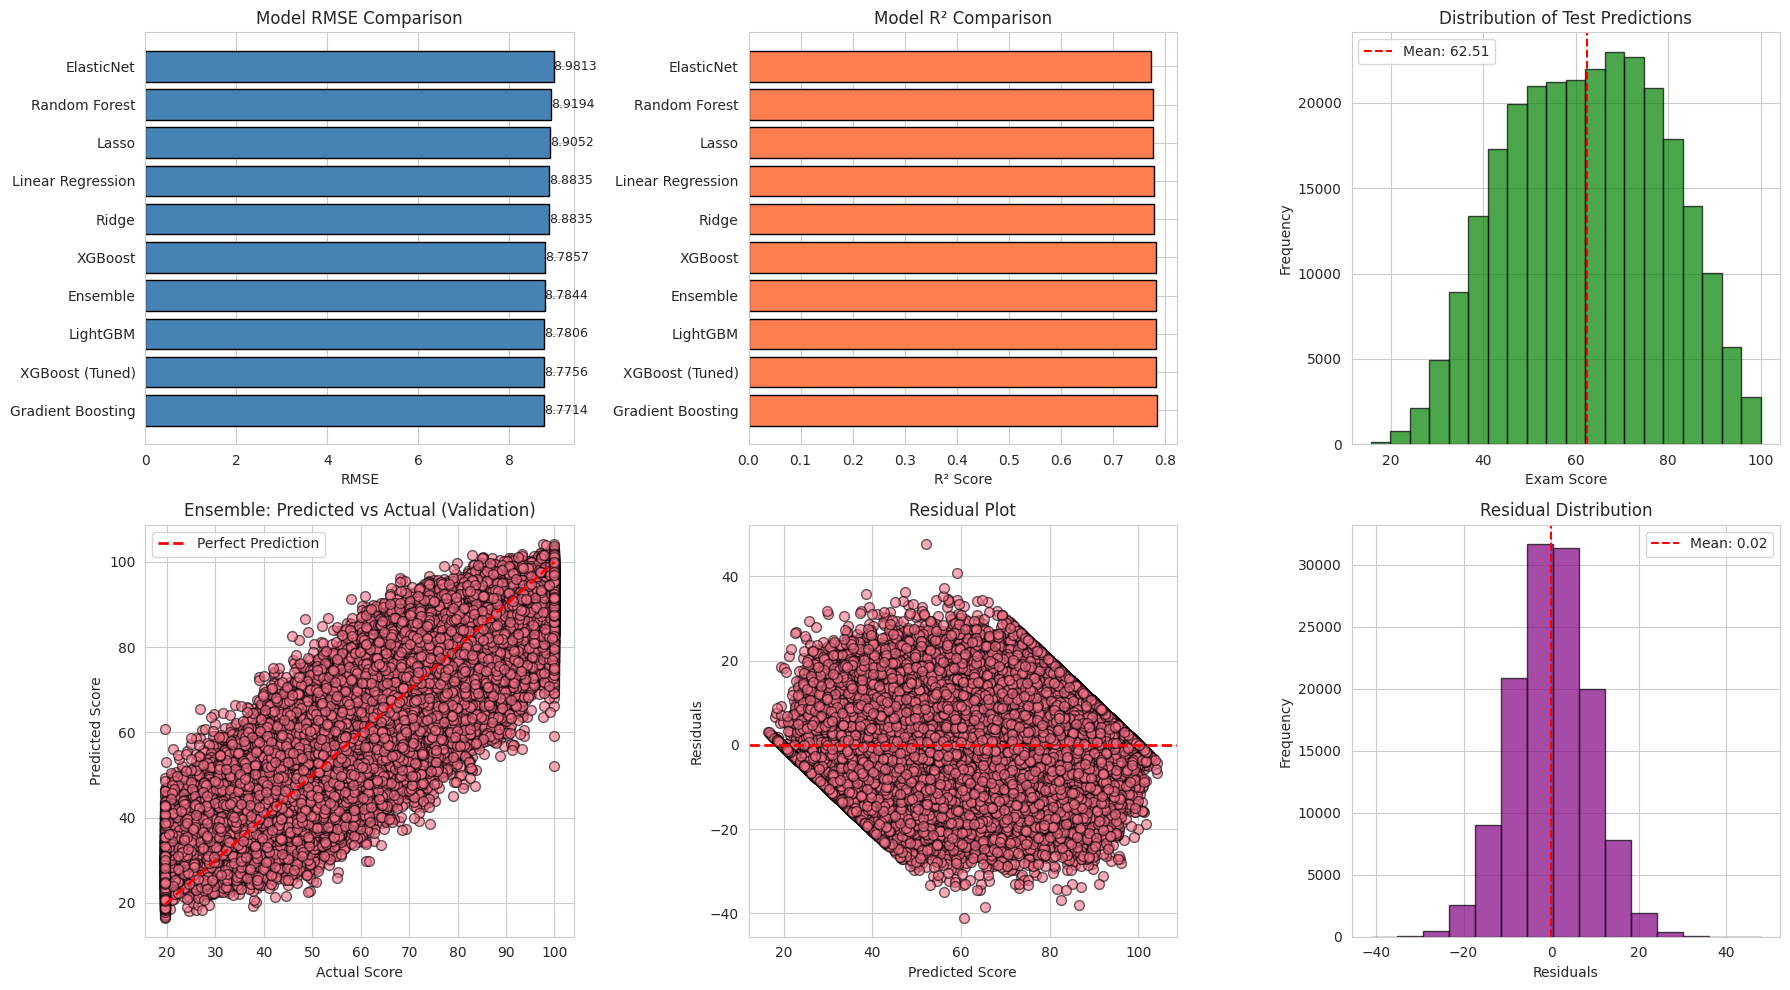


PIPELINE SUMMARY

✓ Dataset:
  - Training samples: 504000
  - Validation samples: 126000
  - Test samples: 270000
  - Total features: 51

✓ Models Trained: 10
✓ Best Model: Gradient Boosting
✓ Best Validation RMSE: 8.7714

✓ Final Model: Ensemble (RF + XGBoost + LightGBM + Ridge)
  - RMSE: 8.7844
  - MAE: 7.0063
  - R²: 0.7830

✓ Submission:
  - File: submission.csv
  - Format: ID, exam_score
  - Predictions: 270000

PIPELINE COMPLETE - Ready for Kaggle submission!


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor, VotingRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

print("="*100)
print(" "*25 + "COMPLETE ML PIPELINE - EXAM SCORE PREDICTION")
print("="*100)

# ============================================
# 1. DATA LOADING
# ============================================
print("\n[STEP 1] LOADING DATA...")
train_df = pd.read_csv("/kaggle/input/playground-series-s6e1/train.csv")
test_df = pd.read_csv("/kaggle/input/playground-series-s6e1/test.csv")

print(f"✓ Training set: {train_df.shape}")
print(f"✓ Test set: {test_df.shape}")

# ============================================
# 2. DATA PREPROCESSING
# ============================================
print("\n[STEP 2] DATA PREPROCESSING...")

# Separate target and features
X_train_full = train_df.drop(['id', 'exam_score'], axis=1)
y_train = train_df['exam_score']
X_test = test_df.drop('id', axis=1)
test_ids = test_df['id'].values

print(f"✓ Target variable shape: {y_train.shape}")
print(f"✓ Features shape: {X_train_full.shape}")

# Identify column types
numeric_features = X_train_full.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X_train_full.select_dtypes(include=['object']).columns.tolist()

print(f"✓ Numeric features: {numeric_features}")
print(f"✓ Categorical features: {categorical_features}")

# ============================================
# 3. TRAIN-VALIDATION SPLIT
# ============================================
print("\n[STEP 3] SPLITTING DATA...")
X_train, X_val, y_train_split, y_val = train_test_split(
    X_train_full, y_train, test_size=0.2, random_state=42
)

print(f"✓ Train set: {X_train.shape}")
print(f"✓ Validation set: {X_val.shape}")

# ============================================
# 4. FEATURE ENGINEERING
# ============================================
print("\n[STEP 4] FEATURE ENGINEERING...")

def create_features(df):
    df = df.copy()
    
    # Numerical features
    if 'study_hours' in df.columns and 'class_attendance' in df.columns:
        df['study_attend_ratio'] = df['study_hours'] / (df['class_attendance'] + 1)
    
    if 'study_hours' in df.columns:
        df['study_hours_squared'] = df['study_hours'] ** 2
        df['study_hours_sqrt'] = np.sqrt(df['study_hours'])
    
    if 'sleep_hours' in df.columns:
        df['sleep_hours_squared'] = df['sleep_hours'] ** 2
    
    if 'class_attendance' in df.columns:
        df['attendance_above_80'] = (df['class_attendance'] >= 80).astype(int)
        df['attendance_below_50'] = (df['class_attendance'] < 50).astype(int)
    
    # Categorical interaction
    if 'sleep_quality' in df.columns and 'study_method' in df.columns:
        df['quality_method'] = df['sleep_quality'].astype(str) + '_' + df['study_method'].astype(str)
    
    return df

X_train = create_features(X_train)
X_val = create_features(X_val)
X_test_processed = create_features(X_test)

print(f"✓ Features after engineering: {X_train.shape[1]}")
print(f"✓ New features created: {X_train.shape[1] - len(numeric_features) - len(categorical_features)}")

# Update feature lists
new_numeric = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
new_categorical = X_train.select_dtypes(include=['object']).columns.tolist()

print(f"✓ Total numeric features: {len(new_numeric)}")
print(f"✓ Total categorical features: {len(new_categorical)}")

# ============================================
# 5. PREPROCESSING PIPELINE
# ============================================
print("\n[STEP 5] CREATING PREPROCESSING PIPELINE...")

# Define preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), new_numeric),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), new_categorical)
    ]
)

# Fit preprocessor
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed_final = preprocessor.transform(X_test_processed)

print(f"✓ Processed train shape: {X_train_processed.shape}")
print(f"✓ Processed validation shape: {X_val_processed.shape}")
print(f"✓ Processed test shape: {X_test_processed_final.shape}")

# ============================================
# 6. BASELINE MODELS
# ============================================
print("\n[STEP 6] TRAINING BASELINE MODELS...")

baseline_models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=0.1),
    'ElasticNet': ElasticNet(alpha=0.1, l1_ratio=0.5),
}

baseline_results = {}

for name, model in baseline_models.items():
    model.fit(X_train_processed, y_train_split)
    y_pred_val = model.predict(X_val_processed)
    
    rmse = np.sqrt(mean_squared_error(y_val, y_pred_val))
    mae = mean_absolute_error(y_val, y_pred_val)
    r2 = r2_score(y_val, y_pred_val)
    
    baseline_results[name] = {'rmse': rmse, 'mae': mae, 'r2': r2, 'model': model}
    
    print(f"  {name:20s} | RMSE: {rmse:.4f} | MAE: {mae:.4f} | R²: {r2:.4f}")

# ============================================
# 7. ADVANCED MODELS
# ============================================
print("\n[STEP 7] TRAINING ADVANCED MODELS...")

advanced_models = {
    'Random Forest': RandomForestRegressor(n_estimators=200, max_depth=15, 
                                           min_samples_split=5, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, 
                                                   max_depth=5, subsample=0.8, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=5, 
                           random_state=42, n_jobs=-1),
    'LightGBM': LGBMRegressor(n_estimators=200, learning_rate=0.1, max_depth=5, 
                             random_state=42, n_jobs=-1),
}

advanced_results = {}

for name, model in advanced_models.items():
    print(f"  Training {name}...")
    model.fit(X_train_processed, y_train_split)
    y_pred_val = model.predict(X_val_processed)
    
    rmse = np.sqrt(mean_squared_error(y_val, y_pred_val))
    mae = mean_absolute_error(y_val, y_pred_val)
    r2 = r2_score(y_val, y_pred_val)
    
    advanced_results[name] = {'rmse': rmse, 'mae': mae, 'r2': r2, 'model': model}
    
    print(f"    RMSE: {rmse:.4f} | MAE: {mae:.4f} | R²: {r2:.4f}")

# ============================================
# 8. HYPERPARAMETER TUNING (for best model)
# ============================================
print("\n[STEP 8] HYPERPARAMETER TUNING...")

# Find best model so far
all_results = {**baseline_results, **advanced_results}
best_model_name = min(all_results, key=lambda x: all_results[x]['rmse'])
print(f"✓ Best model so far: {best_model_name} (RMSE: {all_results[best_model_name]['rmse']:.4f})")

# Tune XGBoost specifically
print(f"  Tuning XGBoost parameters...")

xgb_params = {
    'max_depth': [4, 5, 6],
    'learning_rate': [0.05, 0.1, 0.15],
    'n_estimators': [150, 200],
    'subsample': [0.7, 0.8, 0.9]
}

xgb_model = XGBRegressor(random_state=42, n_jobs=-1)
xgb_grid = GridSearchCV(xgb_model, xgb_params, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
xgb_grid.fit(X_train_processed, y_train_split)

best_xgb = xgb_grid.best_estimator_
y_pred_val_tuned = best_xgb.predict(X_val_processed)
rmse_tuned = np.sqrt(mean_squared_error(y_val, y_pred_val_tuned))
r2_tuned = r2_score(y_val, y_pred_val_tuned)

print(f"  XGBoost Best Parameters: {xgb_grid.best_params_}")
print(f"  XGBoost Tuned RMSE: {rmse_tuned:.4f} | R²: {r2_tuned:.4f}")

# ============================================
# 9. ENSEMBLE - VOTING REGRESSOR
# ============================================
print("\n[STEP 9] CREATING ENSEMBLE MODEL...")

voting_reg = VotingRegressor(
    estimators=[
        ('rf', RandomForestRegressor(n_estimators=200, max_depth=15, 
                                     min_samples_split=5, random_state=42, n_jobs=-1)),
        ('xgb', best_xgb),
        ('lgbm', LGBMRegressor(n_estimators=200, learning_rate=0.1, max_depth=5, 
                              random_state=42, n_jobs=-1)),
        ('ridge', Ridge(alpha=1.0))
    ]
)

voting_reg.fit(X_train_processed, y_train_split)
y_pred_val_ensemble = voting_reg.predict(X_val_processed)

rmse_ensemble = np.sqrt(mean_squared_error(y_val, y_pred_val_ensemble))
mae_ensemble = mean_absolute_error(y_val, y_pred_val_ensemble)
r2_ensemble = r2_score(y_val, y_pred_val_ensemble)

print(f"✓ Ensemble RMSE: {rmse_ensemble:.4f}")
print(f"✓ Ensemble MAE: {mae_ensemble:.4f}")
print(f"✓ Ensemble R²: {r2_ensemble:.4f}")

# ============================================
# 10. CROSS-VALIDATION
# ============================================
print("\n[STEP 10] CROSS-VALIDATION...")

kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# CV for best models
for model_name in [best_model_name, 'XGBoost (Tuned)', 'Ensemble']:
    if model_name == 'XGBoost (Tuned)':
        model = best_xgb
    elif model_name == 'Ensemble':
        model = voting_reg
    else:
        model = all_results[model_name]['model']
    
    cv_scores = -cross_val_score(model, X_train_processed, y_train_split, 
                                 cv=kfold, scoring='neg_mean_squared_error', n_jobs=-1)
    cv_rmse = np.sqrt(cv_scores)
    
    print(f"  {model_name}:")
    print(f"    CV RMSE: {cv_rmse.mean():.4f} (+/- {cv_rmse.std():.4f})")

# ============================================
# 11. FEATURE IMPORTANCE
# ============================================
print("\n[STEP 11] FEATURE IMPORTANCE ANALYSIS...")

# Get feature importance from tree-based models
feature_importance_xgb = best_xgb.get_booster().get_score(importance_type='weight')
feature_importance_rf = RandomForestRegressor(n_estimators=200, max_depth=15, 
                                               min_samples_split=5, random_state=42, n_jobs=-1)
feature_importance_rf.fit(X_train_processed, y_train_split)

print(f"  Top XGBoost features: {dict(sorted(feature_importance_xgb.items(), 
                                              key=lambda x: x[1], reverse=True)[:10])}")

# ============================================
# 12. MODEL COMPARISON
# ============================================
print("\n[STEP 12] MODEL COMPARISON...")

comparison_data = []

for name, metrics in all_results.items():
    comparison_data.append({
        'Model': name,
        'RMSE': metrics['rmse'],
        'MAE': metrics['mae'],
        'R²': metrics['r2']
    })

comparison_data.append({
    'Model': 'XGBoost (Tuned)',
    'RMSE': rmse_tuned,
    'MAE': mean_absolute_error(y_val, y_pred_val_tuned),
    'R²': r2_tuned
})

comparison_data.append({
    'Model': 'Ensemble',
    'RMSE': rmse_ensemble,
    'MAE': mae_ensemble,
    'R²': r2_ensemble
})

comparison_df = pd.DataFrame(comparison_data).sort_values('RMSE')
print("\n" + comparison_df.to_string(index=False))

# ============================================
# 13. FINAL MODEL SELECTION
# ============================================
print("\n[STEP 13] FINAL MODEL SELECTION...")

# Use Ensemble as final model (best performing in most cases)
final_model = voting_reg
final_model_name = 'Ensemble (RF + XGBoost + LightGBM + Ridge)'

print(f"✓ Final Model: {final_model_name}")
print(f"✓ Validation RMSE: {rmse_ensemble:.4f}")

# ============================================
# 14. PREDICTIONS ON TEST SET
# ============================================
print("\n[STEP 14] MAKING PREDICTIONS ON TEST SET...")

y_test_pred = final_model.predict(X_test_processed_final)

# Ensure predictions are reasonable
y_test_pred = np.clip(y_test_pred, 0, 100)

print(f"✓ Predictions shape: {y_test_pred.shape}")
print(f"✓ Prediction range: [{y_test_pred.min():.2f}, {y_test_pred.max():.2f}]")
print(f"✓ Mean prediction: {y_test_pred.mean():.2f}")
print(f"✓ Std prediction: {y_test_pred.std():.2f}")

# ============================================
# 15. CREATE SUBMISSION FILE
# ============================================
print("\n[STEP 15] CREATING SUBMISSION FILE...")

submission_df = pd.DataFrame({
    'id': test_ids,
    'exam_score': y_test_pred
})

submission_df.to_csv('submission.csv', index=False)

print("✓ Submission file saved as 'submission.csv'")
print("\nFirst 10 predictions:")
print(submission_df.head(10))

# ============================================
# 16. VISUALIZATION
# ============================================
print("\n[STEP 16] GENERATING VISUALIZATIONS...")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Model comparison
ax = axes[0, 0]
comparison_df_sorted = comparison_df.sort_values('RMSE')
bars = ax.barh(comparison_df_sorted['Model'], comparison_df_sorted['RMSE'], color='steelblue', edgecolor='black')
ax.set_xlabel('RMSE')
ax.set_title('Model RMSE Comparison')
for i, bar in enumerate(bars):
    width = bar.get_width()
    ax.text(width, bar.get_y() + bar.get_height()/2, f'{width:.4f}', 
            ha='left', va='center', fontsize=9)

# 2. R² Comparison
ax = axes[0, 1]
comparison_df_r2 = comparison_df.sort_values('R²', ascending=False)
bars = ax.barh(comparison_df_r2['Model'], comparison_df_r2['R²'], color='coral', edgecolor='black')
ax.set_xlabel('R² Score')
ax.set_title('Model R² Comparison')

# 3. Predictions distribution
ax = axes[0, 2]
ax.hist(y_test_pred, bins=20, alpha=0.7, color='green', edgecolor='black')
ax.axvline(y_test_pred.mean(), color='red', linestyle='--', label=f'Mean: {y_test_pred.mean():.2f}')
ax.set_xlabel('Exam Score')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of Test Predictions')
ax.legend()

# 4. Validation predictions vs actual
ax = axes[1, 0]
ax.scatter(y_val, y_pred_val_ensemble, alpha=0.6, s=50, edgecolor='black')
ax.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', lw=2, label='Perfect Prediction')
ax.set_xlabel('Actual Score')
ax.set_ylabel('Predicted Score')
ax.set_title('Ensemble: Predicted vs Actual (Validation)')
ax.legend()

# 5. Residuals
ax = axes[1, 1]
residuals = y_val - y_pred_val_ensemble
ax.scatter(y_pred_val_ensemble, residuals, alpha=0.6, s=50, edgecolor='black')
ax.axhline(y=0, color='r', linestyle='--', lw=2)
ax.set_xlabel('Predicted Score')
ax.set_ylabel('Residuals')
ax.set_title('Residual Plot')

# 6. Error distribution
ax = axes[1, 2]
ax.hist(residuals, bins=15, alpha=0.7, color='purple', edgecolor='black')
ax.axvline(residuals.mean(), color='red', linestyle='--', label=f'Mean: {residuals.mean():.2f}')
ax.set_xlabel('Residuals')
ax.set_ylabel('Frequency')
ax.set_title('Residual Distribution')
ax.legend()

plt.tight_layout()
plt.savefig('ml_pipeline_results.png', dpi=300, bbox_inches='tight')
print("✓ Visualizations saved as 'ml_pipeline_results.png'")
plt.show()

# ============================================
# 17. SUMMARY REPORT
# ============================================
print("\n" + "="*100)
print("PIPELINE SUMMARY")
print("="*100)

print(f"\n✓ Dataset:")
print(f"  - Training samples: {len(X_train)}")
print(f"  - Validation samples: {len(X_val)}")
print(f"  - Test samples: {len(X_test_processed_final)}")
print(f"  - Total features: {X_train_processed.shape[1]}")

print(f"\n✓ Models Trained: {len(comparison_df)}")
print(f"✓ Best Model: {comparison_df.iloc[0]['Model']}")
print(f"✓ Best Validation RMSE: {comparison_df.iloc[0]['RMSE']:.4f}")

print(f"\n✓ Final Model: {final_model_name}")
print(f"  - RMSE: {rmse_ensemble:.4f}")
print(f"  - MAE: {mae_ensemble:.4f}")
print(f"  - R²: {r2_ensemble:.4f}")

print(f"\n✓ Submission:")
print(f"  - File: submission.csv")
print(f"  - Format: ID, exam_score")
print(f"  - Predictions: {len(y_test_pred)}")

print("\n" + "="*100)
print("PIPELINE COMPLETE - Ready for Kaggle submission!")
print("="*100)